In [6]:
# Q9
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
%matplotlib inline
import cv2


In [7]:
def generate_shape(shape, size=64):
    img = np.zeros((size, size), dtype=np.uint8)

    if shape == "circle":
        cv2.circle(img, (size//2, size//2), size//4, 255, -1)

    elif shape == "square":
        cv2.rectangle(img, (size//4, size//4), (3*size//4, 3*size//4), 255, -1)

    elif shape == "triangle":
        pts = np.array([
            [size//2, size//4],
            [size//4, 3*size//4],
            [3*size//4, 3*size//4]
        ])
        cv2.drawContours(img, [pts], 0, 255, -1)

    else:
        return 'Please choose a shape from circle, square or triangle only. '
    
    return img

In [8]:
shapes = ["circle", "square", "triangle"]
X = []
y = []

for label, shape in enumerate(shapes):
    for _ in range(100):  
        img = generate_shape(shape)
        X.append(img.flatten())  
        y.append(label)

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

model_1 = KNeighborsClassifier()
model_1.fit(X_train, y_train)

model_2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean', n_jobs=3)
model_2.fit(X_train, y_train)

y_pred_model_1 = model_1.predict(X_test)
y_pred_model_2 = model_2.predict(X_test)

print("Model 1 Accuracy:", accuracy_score(y_test, y_pred_model_1))
print("Model 1 Accuracy:", accuracy_score(y_test, y_pred_model_2))
print('\nModel 2',classification_report(y_test, y_pred_model_1))
print('\nModel 2', classification_report(y_test, y_pred_model_2))

Model 1 Accuracy: 1.0
Model 1 Accuracy: 1.0

Model 2               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60


Model 2               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



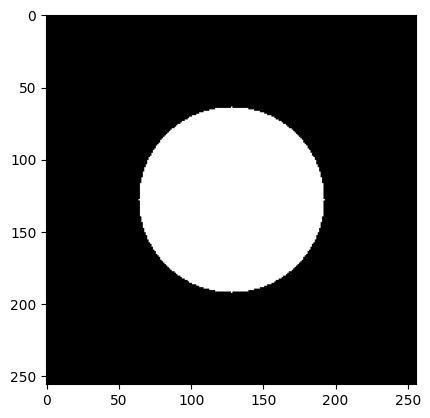

In [9]:
plt.imshow(generate_shape('circle', size=256),cmap='gray');

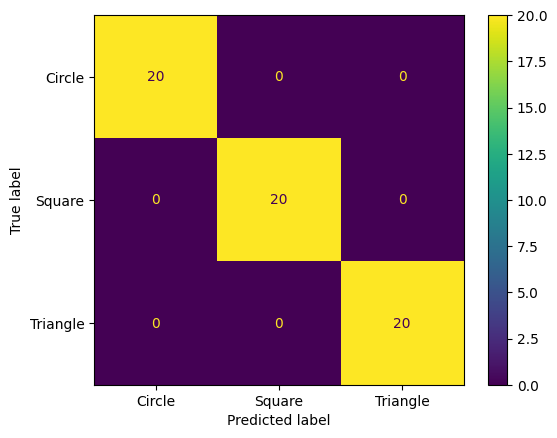

In [10]:
cm = confusion_matrix(y_test,y_pred_model_1)
ConfusionMatrixDisplay(cm, display_labels=['Circle','Square','Triangle']).plot(cmap='viridis');